# 손동작 의도 분류 EEG 디코더로 AmazingHand 구동

`neural-to-output` 프로젝트와 독립적인 sandbox입니다 (`pyproject.toml`/`uv.lock` 미수정, `01_explore_eeg_decoder.ipynb`와
같은 `examples` 의존성 그룹만 사용합니다).

**목표**: EEG 신호를 BCI Competition IV 2a(`BNCI2014_001`, moabb)의 원본 4클래스(`feet`, `left_hand`,
`right_hand`, `tongue`) 그대로 분류하는 디코더를 만들고, 그 출력을 `n2o.decoder.Classification`
서브클래스로 감싸서 `N2O` 파이프라인을 통해 `n2o.robot.hand.AmazingHand`까지 명령을 전달합니다. 디코더는
데이터셋의 원시 라벨을 그대로 반환할 뿐이고, 그 라벨을 실제 손동작(`grip`/`release`/`index_pointing`/
`perfect`)으로 바꾸는 건 `Command`의 역할입니다. 그리고 실제 [AmazingHand](https://github.com/pollen-robotics/AmazingHand)
CAD로 만든 MuJoCo 모델을 직접 관절 제어해서, 그 명령대로 손이 움직이는 모습을 애니메이션으로 봅니다.

**하드웨어 관련 캐비잇**: `n2o.robot.hand.AmazingHand`는 이제 `rustypot` 기반 실제 서보 드라이버입니다
(`n2o.robot.Part`를 상속) — `move(cmd)`가 실제 하드웨어를 구동하고, `goal(cmd)`는 순수 계산(`GESTURES[cmd]`
조회, I/O 없음)만 합니다. 이 노트북은 실제 손 없이도 돌아가도록, `move()`(실제 하드웨어)가 아니라
`goal()` + `n2o.robot.simulation.Simulator`로 손이 움직이는 모습을 재생합니다 — 아래 5절 참고. 출처/
라이선스는 `examples/assets/amazing_hand_right/NOTICE.md` 참고.

In [ ]:
import os
import warnings

os.environ.setdefault(
    "MUJOCO_GL", "egl"
)  # 디스플레이 없는 환경에서도 오프스크린 렌더링

import matplotlib.pyplot as plt
import mne
import numpy as np
import torch
from braindecode.models import EEGNet
from braindecode.preprocessing import create_windows_from_events

from n2o import N2O
from n2o.command import CommandConfig, GripSpreadCommand
from n2o.decoder import (
    Classification,
    DecoderConfig,
    DecoderType,
    FeatureType,
    bandpass_standardize,
    label_names,
)
from n2o.robot.hand.amazing_hand import AmazingHand
from n2o.signal.dataset import DatasetLoader

warnings.filterwarnings("ignore")  # mne/braindecode의 사소한 UserWarning 숨김
mne.set_log_level("ERROR")  # mne의 시끄러운 필터 설계 로그(INFO) 숨김

## 1. EEG 데이터 로드 및 전처리

`01_explore_eeg_decoder.ipynb`와 동일한 subject 1 데이터를, 이번엔 `braindecode.datasets.MOABBDataset`를
직접 부르는 대신 `n2o.signal.dataset.DatasetLoader`로 불러옵니다(내부적으로 `moabb_entry.py`가 같은 일을
합니다). 전처리도 `Preprocessor` 리스트를 직접 조합하는 대신 `n2o.decoder.bandpass_standardize()` 하나로
같은 밴드패스(4-38Hz) + 표준화를 적용합니다 (그 안에서 무슨 일이 일어나는지는 `01_explore_eeg_decoder.ipynb`
참고).

In [ ]:
dataset = DatasetLoader(
    name="BNCI2014_001"
).read()  # subject 1의 raw 레코딩만 (n2o.signal의 역할은 로딩까지)
bandpass_standardize(
    dataset
)  # 4-38Hz 밴드패스 + exponential-moving-standardize, in place -- n2o.decoder의 역할

raw = dataset.datasets[0].raw
print("preprocessed n_channels:", len(raw.ch_names))
print("preprocessed data shape:", raw.get_data().shape)

## 2. 윈도잉

`create_windows_from_events()`로 각 트라이얼을 이벤트(큐) 기준 윈도우 하나로 자릅니다 — 클래스는
데이터셋 원본 그대로(`feet`, `left_hand`, `right_hand`, `tongue`) 4개입니다. `label_names()`가 그
클래스 인덱스 순서를 `windows_dataset` 자신의 이벤트 매핑에서 읽어옵니다.

In [ ]:
sfreq = dataset.datasets[0].raw.info["sfreq"]
trial_start_offset_samples = int(-0.5 * sfreq)

windows_dataset = create_windows_from_events(
    dataset,
    trial_start_offset_samples=trial_start_offset_samples,
    trial_stop_offset_samples=0,
    preload=True,
)
LABEL_NAMES = label_names(windows_dataset)

splitted = windows_dataset.split("session")
train_key, valid_key = list(splitted.keys())[:2]
train_set = splitted[train_key]
valid_set = splitted[valid_key]

X0, y0, _ = train_set[0]
n_chans, input_window_samples = X0.shape
print(f"train trials: {len(train_set)}, valid trials: {len(valid_set)}")
print(f"n_chans={n_chans}, n_times={input_window_samples}")
print("한 샘플 라벨:", LABEL_NAMES[y0])

In [ ]:
from collections import Counter

train_counts = Counter(train_set[i][1] for i in range(len(train_set)))
valid_counts = Counter(valid_set[i][1] for i in range(len(valid_set)))

x = np.arange(len(LABEL_NAMES))
width = 0.35
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(
    x - width / 2,
    [train_counts[i] for i in range(len(LABEL_NAMES))],
    width,
    label="train",
)
ax.bar(
    x + width / 2,
    [valid_counts[i] for i in range(len(LABEL_NAMES))],
    width,
    label="valid",
)
ax.set_xticks(x)
ax.set_xticklabels(LABEL_NAMES)
ax.set_ylabel("number of trials")
ax.set_title("Trials per class")
ax.legend()
plt.tight_layout()
plt.show()

## 3. `Decoder` 서브클래스: EEGNet 기반 4클래스 분류기

`n2o.decoder.Classification`을 상속해서 `decode(signal)`이 raw EEG 윈도우를 데이터셋 원시 라벨
문자열(`"feet"`/`"left_hand"`/`"right_hand"`/`"tongue"`) 그대로 반환하도록 감쌉니다 — 로봇이 몇 개인지,
그 라벨을 어떤 손동작으로 옮길지는 전혀 모릅니다. `Decoder`를 직접 상속하지 않는 이유는 `Classification`이
이산 클래스 라벨 디코더용 `preprocess()`/`window()`(각각 `bandpass_standardize()`/`window_by_event()`)를
이미 구현해두고 있어서, `decode()`만 새로 작성하면 되기 때문입니다. `output_type = FeatureType.ACTION`으로
선언하면 `N2O.run()`이 이 출력을 `Command`를 거쳐 로봇으로 전달합니다.

이 원시 라벨을 실제 손동작으로 옮기는 건 `n2o.command.GripSpreadCommand`(다음 절에서 씀)가 담당합니다.

In [ ]:
class MotorImageryDecoder(Classification):
    """EEGNet 기반 4클래스(feet/left_hand/right_hand/tongue) 운동 심상 분류기 -- 데이터셋
    원시 라벨을 그대로 반환할 뿐, 로봇 쪽 사정은 전혀 모릅니다."""

    output_type = FeatureType.ACTION

    def __init__(self, n_chans, n_times):
        self.input_spec = {"n_chans": n_chans, "n_times": n_times}
        self.output_spec = {"label": " | ".join(LABEL_NAMES)}
        self.config = DecoderConfig(type=DecoderType.CLASSIFICATION)
        self.model = EEGNet(
            n_chans=n_chans, n_outputs=len(LABEL_NAMES), n_times=n_times
        )

    @property
    def device(self):
        # print(model)이 내부적으로 torchinfo summary를 실행하면서 모델을 GPU로 옮길 수 있어,
        # 캐싱하지 않고 매번 모델의 실제 현재 위치를 조회합니다.
        return next(self.model.parameters()).device

    def decode(self, signal):
        self.model.eval()
        with torch.no_grad():
            x = torch.tensor(signal).unsqueeze(0).float().to(self.device)
            logits = self.model(x)
        return LABEL_NAMES[int(logits.argmax(dim=1).item())]


decoder = MotorImageryDecoder(n_chans=n_chans, n_times=input_window_samples)
print(decoder.model)

## 4. 학습 sanity check

`01_explore_eeg_decoder.ipynb`와 동일하게, 작은 고정 배치 하나를 반복 학습시켜서 loss가 떨어지고
accuracy가 오르는지만 확인하는 오버피팅 sanity check입니다 (제대로 된 학습이 아님).

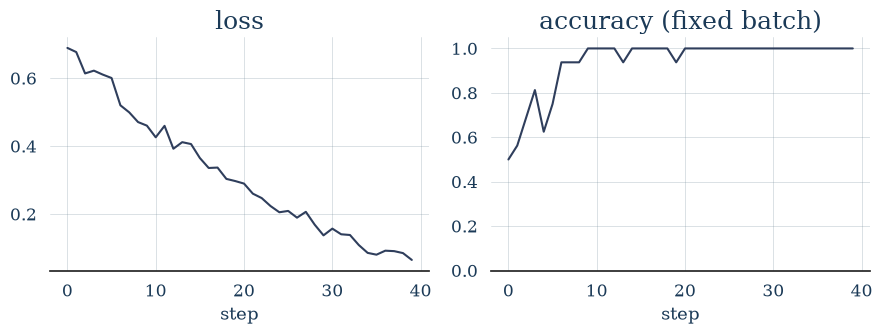

마지막 step: loss=0.0650, acc=1.00


In [6]:
decoder.model.train()
opt = torch.optim.Adam(decoder.model.parameters(), lr=1e-3)
loss_fn = torch.nn.CrossEntropyLoss()

n_batch = min(16, len(train_set))
xs = np.stack([train_set[i][0] for i in range(n_batch)])
ys = np.array([train_set[i][1] for i in range(n_batch)])
X_batch = torch.from_numpy(xs).float().to(decoder.device)
y_batch = torch.from_numpy(ys).long().to(decoder.device)

n_steps = 40
history = {"loss": [], "acc": []}
for step in range(n_steps):
    opt.zero_grad()
    logits = decoder.model(X_batch)
    loss = loss_fn(logits, y_batch)
    loss.backward()
    opt.step()
    acc = (logits.argmax(dim=1) == y_batch).float().mean().item()
    history["loss"].append(loss.item())
    history["acc"].append(acc)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].plot(history["loss"])
axes[0].set_title("loss")
axes[0].set_xlabel("step")
axes[1].plot(history["acc"])
axes[1].set_title("accuracy (fixed batch)")
axes[1].set_xlabel("step")
axes[1].set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

print(f"마지막 step: loss={history['loss'][-1]:.4f}, acc={history['acc'][-1]:.2f}")

## 5. MuJoCo로 실제 AmazingHand 모델 시각화하기

`n2o.robot.hand.AmazingHand`는 `n2o.robot.Part`를 상속합니다 — `move()`가 실제 하드웨어를 움직이고,
`goal()`은 순수 계산(`GESTURES[cmd]` 조회, I/O 없음)만 합니다. 여기서는 실제 손 없이도 `goal()`이
계산한 타깃을, pollen-robotics의 실제 CAD 기반 MuJoCo 모델(`examples/assets/amazing_hand_right/`,
출처/라이선스는 같은 폴더의 `NOTICE.md` 참고)로 시각화합니다.

`n2o.robot.Robot` + `ControllerType.SIMULATION` + `n2o.robot.simulation.Simulator`를 직접 구성해서
`Robot.router()`를 호출하면, `SIMULATION` 모드이므로 실제 서보에는 아무것도 보내지 않고
`AmazingHand.goal()`만 호출한 뒤 그 결과를 `Simulator.drive()`에 넘겨 물리 모델을 움직입니다.
`Simulator.launch_viewer("hand")`로 연 라이브 뷰어 창에 그 움직임이 실시간으로 반영됩니다.

`AmazingHand.GESTURES`(`src/n2o/robot/hand/amazing_hand.py`)에는 `grip`/`release`/`open_hand`/
`close_hand`/`clench_hand`/`victory`/`index_pointing`/`nonono`/`perfect` 9개 pose가 정의돼 있습니다 —
여기서는 시각적으로 구분되는 네 가지(`grip`/`release`/`victory`/`perfect`)만 데모로 보여줍니다.

**참고**: `launch_viewer()`는 실제 디스플레이가 있어야 뜨는 라이브 GLFW 창입니다 — 위 셀에서 설정한
`MUJOCO_GL=egl`은 오프스크린 렌더링(`Simulator.render()`)에만 적용되고, `launch_viewer()`는 이와 별개로
실제 화면이 필요합니다. 디스플레이 없는 환경에서는 `Simulator.render(part)`로 프레임 배열을 직접 얻어
`matplotlib`으로 표시하는 방식을 대신 쓰세요.

In [ ]:
from n2o.robot import ControllerType, Robot
from n2o.robot.simulation import Simulator

demo_robot = Robot()
demo_robot.hand = AmazingHand()
demo_robot.controller = ControllerType.SIMULATION
demo_robot.simulator = Simulator()
demo_robot.simulator.launch_viewer("hand")

for gesture in ["grip", "release", "victory", "perfect"]:
    print("gesture:", gesture)
    demo_robot.router({"hand": gesture, "arm": None})

## 6. `N2O` 파이프라인으로 AmazingHand까지 명령 전달

`signal.read()`가 매번 같은 검증 샘플을 돌려주는 초간단 signal 소스로 `N2O`를 구성하고,
`n2o.robot.hand = AmazingHand()`를 그대로 연결합니다 (`n2o.robot.arm`은 이 노트북에서 쓰지 않으므로
`None`인 채로 둡니다). `AmazingHand`는 이제 진짜 하드웨어 드라이버이므로, `n2o.run(controller=
"simulation")`을 호출하면 실제 서보에는 아무것도 보내지 않고(`Part.goal()`만 호출) `N2O.run()`이 자동으로
만든 `Simulator`가 라이브 뷰어를 띄워 `GripSpreadCommand`가 매핑한 손동작대로 손이 움직이는 모습을
보여줍니다. 실제 손을 연결한 상태라면 `n2o.run()`(기본값 `controller="motor_driver"`)로 같은 파이프라인이
진짜 서보를 구동합니다 — 이 노트북은 실제 하드웨어 없이도 돌아가도록 시뮬레이션 경로만 실행합니다.

In [ ]:
X_valid, y_valid, _ = valid_set[0]


class OneShotSignal:
    """decoder()에 넘길 신호 한 개를 반복해서 돌려주는 최소 signal 소스."""

    def __init__(self, sample):
        self.sample = sample

    def read(self):
        return self.sample


n2o = N2O()
n2o.signal = OneShotSignal(X_valid)
n2o.decoder = decoder
n2o.command = GripSpreadCommand()
n2o.robot.hand = AmazingHand()

n2o.command_config = CommandConfig()
print(n2o.command_config.verify_report(n2o))
print()
print("실제 라벨:", LABEL_NAMES[y_valid])
print("디코더 명령:", decoder(X_valid))

In [ ]:
n2o.run(controller="simulation")

## 정리

- `n2o.decoder.Classification`을 상속한 `MotorImageryDecoder`는 EEGNet의 예측을 데이터셋 원시
  라벨(`"feet"`/`"left_hand"`/`"right_hand"`/`"tongue"`) 그대로 반환하는 순수 분류기입니다 —
  로봇 쪽 사정을 전혀 모릅니다. `output_type = FeatureType.ACTION`으로 선언해 `N2O.run()`이
  `Command`를 거쳐 로봇으로 명령을 보내도록 했습니다.
- `n2o.command.GripSpreadCommand`(`src/n2o/command/grip_spread.py`)가 그 4개 원시 라벨을 손동작
  이름(`feet`->`index_pointing`, `left_hand`->`grip`, `right_hand`->`release`, `tongue`->`perfect`)으로
  매핑합니다 — 라벨을 로봇 행동으로 바꾸는 건 디코더가 아니라 `Command`의 역할이라는 원칙을 그대로
  따르면서도, 이 매핑은 다른 노트북에서도 재사용할 수 있도록 `n2o.command`에 실제로 구현해뒀습니다.
  (`LABEL_TO_GESTURE`의 값 4개 모두 지금 `AmazingHand.GESTURES`에 실제로 존재하는 이름입니다 — 임의로
  고른 매핑이라는 점은 `OfnerCommand`와 동일하지만, 최소한 깨지지는 않습니다.)
- `CommandConfig.verify_report()`로 파이프라인 경계를 확인했습니다: `AmazingHand`는 이제 실제
  드라이버라 (예전처럼 노트북이 임의로 `input_spec`을 붙인 시뮬레이션 클래스를 쓰지 않으므로)
  `command -> robot.hand` 경계는 "미정"으로 표시됩니다 — `AmazingHand`가 계약을 어겼다는 뜻이 아니라,
  아직 그 계약을 선언해두지 않았다는 뜻입니다.
- `n2o.robot.Part`(`AmazingHand`가 상속)는 `goal(cmd)`(순수 계산)과 `move(cmd)`(실제 하드웨어 구동)를
  분리합니다. `n2o.run(controller="simulation")`은 `move()`를 전혀 부르지 않고 `goal()`만 호출한 뒤
  자동으로 띄운 `Simulator`가 그 타깃을 pollen-robotics의 실제 CAD 기반 MuJoCo 모델에 그대로
  반영해서, 실제 하드웨어 없이도 명령대로 손이 움직이는 모습을 확인할 수 있습니다. 실제 손을
  연결했다면 `controller="motor_driver"`(기본값)로 같은 파이프라인이 진짜 서보를 구동합니다.
- `n2o.signal`만 실제 구현으로 바꿔 끼우면, 이 노트북의 나머지 구조(디코더/`Command`/`AmazingHand`)는
  그대로 재사용됩니다.